In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [44]:
#Carregar base de dados
file_path = '/home/eduardo/Área de Trabalho/Cases/XVendas/src/Case_Vaga_Analista_Intelligence_1.xlsx'
df_case= pd.read_excel(file_path)
pd.options.display.float_format = '{:.2f}'.format


#Exibir Estrutura dos dados

print(df_case.head())
print(df_case.info())
print(df_case.describe())





   Mês           Categoria  Custo Entrega  Custo dos Produtos  Custo Marketing
0    1            AC AUDIO       80353.50            36247.58         11352.35
1    1       AC BT SPEAKER       45448.47            82168.28         19423.72
2    1      AC CALCULADORA        2253.74             3309.12           813.30
3    1        AC CELULARES       22829.13            18308.66          5471.04
4    1  AC ELETRODOMESTICO         432.08               76.29            33.11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3521 entries, 0 to 3520
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Mês                 3521 non-null   int64  
 1   Categoria           3521 non-null   object 
 2   Custo Entrega       3521 non-null   float64
 3   Custo dos Produtos  3521 non-null   float64
 4   Custo Marketing     3521 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 137.7+ KB
None
        

In [45]:

#Otimização de memória convertendo coluna tipo object para category.

if 'Categoria' in df_case.columns:
    memory_before = df_case.memory_usage(deep=True)
    print("Uso de memória antes da conversão:")
    print(memory_before)

    df_case['Categoria'] = df_case['Categoria'].astype('category')

    memory_after = df_case.memory_usage(deep=True)
    print("Uso de memória depois da conversão:")
    print(memory_after)
    
    print("Diferença no uso de memória:")
    print(memory_before - memory_after)
else:
    print("A coluna 'Categoria' não existe no DataFrame.")


Uso de memória antes da conversão:
Index                    128
Mês                    28168
Categoria             256358
Custo Entrega          28168
Custo dos Produtos     28168
Custo Marketing        28168
dtype: int64
Uso de memória depois da conversão:
Index                   128
Mês                   28168
Categoria             54699
Custo Entrega         28168
Custo dos Produtos    28168
Custo Marketing       28168
dtype: int64
Diferença no uso de memória:
Index                      0
Mês                        0
Categoria             201659
Custo Entrega              0
Custo dos Produtos         0
Custo Marketing            0
dtype: int64


Média do custo de entrega antes do quinto mês: 199433.21
Média do custo de entrega após o quinto mês: 557535.82
Percentual de aumento no custo de entrega: 179.56%


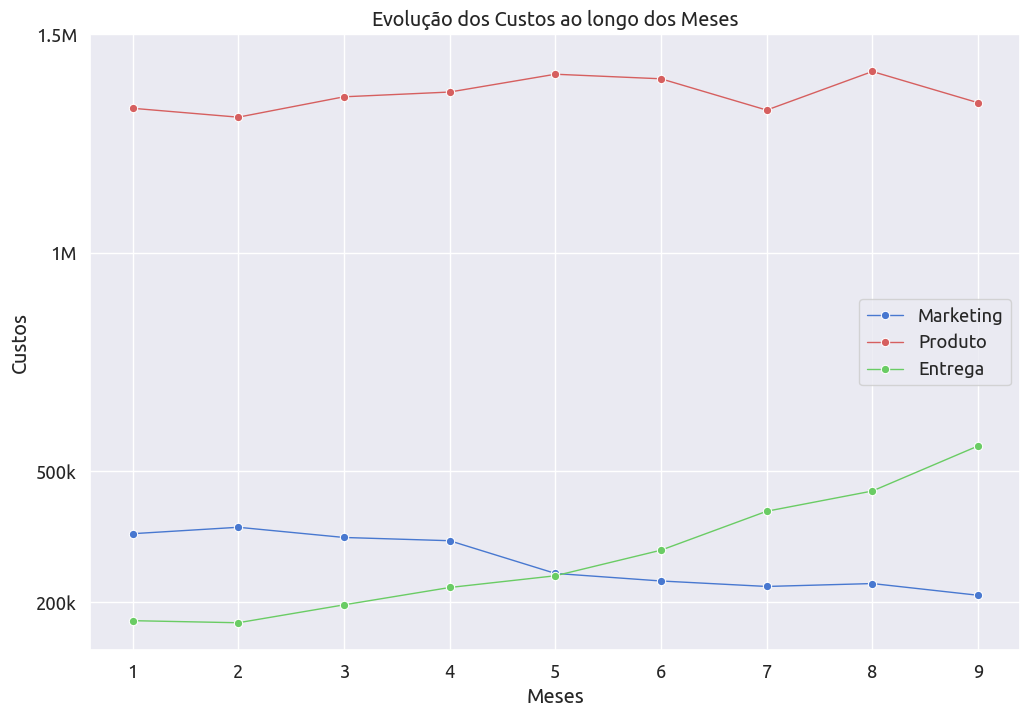

In [47]:
#Análise da progressão do custo ao decorrer do tempo

dados_antes = df_case[df_case['Mês'] <= 5]
dados_depois = df_case[df_case['Mês'] >= 9]

# Calculando a média do custo de entrega antes e depois do quinto mês
media_antes = dados_antes['Custo Entrega'].mean().round(2)
media_depois = dados_depois['Custo Entrega'].mean().round(2)

# Calculando o percentual de aumento
percentual_aumento = ((media_depois - media_antes) / media_antes) * 100
percentual_aumento = percentual_aumento.round(2)
sns.set_theme(style='dark', palette='muted', font='ubuntu', font_scale=1.2)

print (f'Média do custo de entrega antes do quinto mês: {media_antes}')
print (f'Média do custo de entrega após o quinto mês: {media_depois}')
print (f'Percentual de aumento no custo de entrega: {percentual_aumento}%')


def lineplot_custos(data):

    plt.figure(figsize=(12, 8))
    sns.lineplot(x='Mês', y='Custo Marketing', data=df_case, errorbar=None, marker='o', label='Marketing', linewidth=1)
    sns.lineplot(x='Mês', y='Custo dos Produtos', data=df_case, errorbar=None, marker='o', color='r', label='Produto', linewidth=1)
    sns.lineplot(x='Mês', y='Custo Entrega', data=df_case, errorbar=None, marker='o', color='g', label='Entrega', linewidth=1)
    plt.title('Evolução dos Custos ao longo dos Meses')
    plt.xlabel('Meses')
    plt.ylabel('Custos')

    plt.yticks([200000, 500000, 1000000, 1500000], ['200k', '500k', '1M', '1.5M'])

    plt.grid(True)
    plt.show()


lineplot_custos(df_case)

In [51]:
df_case.sort_values(by='Custo Entrega', ascending=False).head(10)

,Mês,Categoria,Custo Entrega,Custo dos Produtos,Custo Marketing
3112,8,TANQUINHO,157937409.32,326211167.38,61256346.68
2485,7,CHURRASCO,78846714.84,77577.79,2440369.96
121,1,CASA CONECTADA,30545784.23,26547.26,550147.80
3472,9,REFRIGERADOR,15249300.85,1112504.29,330963.78
2320,6,SMARTPHONE,12729098.02,59515123.41,9393167.60
3277,9,COLCHÕES,10623745.12,143893.02,58427.22
3347,9,FOGAO,9395114.08,378972.08,88591.50
1932,5,SMARTPHONE,9370373.66,21626350.42,2635276.58
1539,4,SMARTPHONE,9078731.20,78879012.86,19078845.23
3487,9,SMARTPHONE,8075770.59,4872084.70,921794.11


### Conclusão:
Ao analisar o gráfico, fica claro que houve um aumento significativo no custo de entrega em comparação aos outros custos. O custo do produto permaneceu constante durante os nove meses, enquanto o custo de marketing por categoria diminuiu nesse período. Por outro lado, o custo de entrega seguiu uma tendência de aumento mês a mês, conforme ilustrado no gráfico.

Considerando que o volume de vendas se manteve estável, o aumento gradual no custo de entrega a partir do segundo mês impacta diretamente o lucro da empresa e, consequentemente, compromete a rentabilidade do XVendas.

O custo de entrega geralmente é composto por custos logísticos e pode ser explicado pelas seguintes variáveis:

1. **Preços dos combustíveis:** O aumento nos preços dos combustíveis afeta diretamente a cadeia logística do XVendas. Quanto maior o preço do combustível, maior o valor do frete para a entrega dos produtos.

2. **Mudanças nos custos trabalhistas:** Aumentos nos salários ou no pagamento de horas extras para as equipes logísticas durante períodos de pico ou devido à escassez de mão de obra aumentam os custos de entrega.

3. **Mudanças regulatórias:** Novas regulamentações ou impostos relacionados aos serviços de transporte e entrega também podem contribuir para o aumento desse custo.

4. **Distribuição geográfica:** Na tentativa de fomentar vendas em regiões geograficamente remotas, menos acessíveis ou distantes dos centros de distribuição e lojas, o custo de frete tende a aumentar devido à distância percorrida para a entrega. Exemplo: As regiões Norte e Nordeste correspondem, somadas, a mais de 63% do território brasileiro, tornando a gestão dos custos de entrega nessas regiões um grande desafio.

## Próximos passos

Na base de dados temos a coluna Categoria, vamos verificar se todos os segmentos de produtos sofreram incremento do **custo de entrega** de forma igual. 

<Axes: >

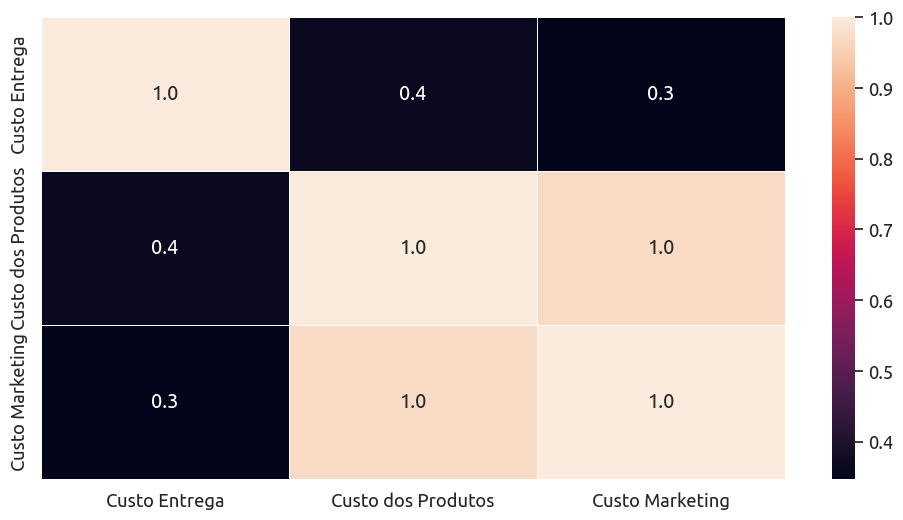

In [59]:
df_custos = df_case.iloc[:, 2:]
correlacao = df_custos.corr()

plt.figure(figsize=(12,6))
sns.heatmap(correlacao, annot = True, fmt=".1f", linewidths=.6 )

## Mapa de Correlação:

Este mapa térmico mostra os coeficientes de correlação entre cada par de variáveis, fornecendo insights sobre como esses custos estão relacionados entre si. Um coeficiente de correlação próximo de 1 indica uma forte correlação positiva, ou seja, à medida que uma variável aumenta, a outra tende a aumentar também. Um coeficiente próximo de -1 indica uma forte correlação negativa, onde uma variável aumenta enquanto a outra diminui. Um coeficiente em torno de 0 sugere não haver correlação linear entre as variáveis.


é possível observar que existe alguma correlação entre os custos:
* Custo de entrega / Custo de Produto = 0.4
* Custo de entrega / Custo de Marketing = 0.3

Notei a presença de muitos outliers nos custos de entrega de categorias, que podem indicar algum erro nos dados. Recomendo fazer uma investigação mais detalhada dos custos de alguns produtos.
Ao Criar uma média geral dos custos alguns itens se destacam, indicando o custo de Entrega até maior que o custo do produto. 


In [61]:
# Calculando a média de cada custo por categoria
df_media_custos = df_case.groupby('Categoria').mean()[['Custo Entrega', 'Custo dos Produtos','Custo Marketing']]

# Ordenando a média do maior para o menor
df_media_custos = df_media_custos.sort_values(by=['Custo Entrega', 'Custo dos Produtos','Custo Marketing'], ascending=False)

#resetando index
df_media_custos = df_media_custos.reset_index()

#formatando os números
df_media_custos['Custo Marketing'] = df_media_custos['Custo Marketing'].round(2)
df_media_custos['Custo dos Produtos'] = df_media_custos['Custo dos Produtos'].round(2)
df_media_custos['Custo Entrega'] = df_media_custos['Custo Entrega'].round(2)

#plotando a tabela
df_media_custos.head(10)


/tmp/ipykernel_5050/1018772678.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_media_custos = df_case.groupby('Categoria').mean()[['Custo Entrega', 'Custo dos Produtos','Custo Marketing']]


,Categoria,Custo Entrega,Custo dos Produtos,Custo Marketing
0,TANQUINHO,19442394.95,37100915.31,7082558.93
1,CHURRASCO,8897384.62,91408.00,293266.77
2,SMARTPHONE,6076185.68,38948853.15,7683598.39
3,REFRIGERADOR,4705456.09,8058888.80,1883068.03
4,TV,4320326.76,17638929.13,3472717.45
5,COLCHÕES,3646112.40,1169234.34,428964.18
6,CASA CONECTADA,3427723.16,38620.70,71670.23
7,FOGAO,3044607.82,2290580.89,647502.70
8,LAVADORA,2968981.62,48457589.76,12158101.28
9,FRALDAS,2371325.34,1165527.56,335568.76


### Conclusão Final

Recomendamos mais detalhes sobre os dados que indicam valores fora do previsto, uma base mais detalhada sobre tais categorias deve ser fornecida.